## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [3]:
data.isna().mean()
#Есть пустые значения

Species                0.000000
Island                 0.000000
Clutch Completion      0.000000
Date Egg               0.000000
Culmen Length (mm)     0.005814
Culmen Depth (mm)      0.005814
Flipper Length (mm)    0.005814
Body Mass (g)          0.005814
Sex                    0.029070
Delta 15 N (o/oo)      0.040698
Delta 13 C (o/oo)      0.037791
dtype: float64

In [4]:
transformed_data = data.dropna()
transformed_data.drop(transformed_data[transformed_data["Sex"] == "."].index, inplace=True) #У одного пингвина в параметре Sex было указано "."
transformed_data.isna().mean()

Species                0.0
Island                 0.0
Clutch Completion      0.0
Date Egg               0.0
Culmen Length (mm)     0.0
Culmen Depth (mm)      0.0
Flipper Length (mm)    0.0
Body Mass (g)          0.0
Sex                    0.0
Delta 15 N (o/oo)      0.0
Delta 13 C (o/oo)      0.0
dtype: float64

In [5]:
transformed_data = pd.get_dummies(transformed_data, columns=["Island", "Clutch Completion", "Sex"], dtype=int)
transformed_data

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen,Clutch Completion_No,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0,1,0,0,1,0,1
1,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,0,1,0,0,1,1,0
2,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1,0,0,0,1,1,0
3,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,0,1,0,0,1,1,0
4,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,382,47.6,18.3,195.0,3850.0,8.83502,-24.65859,0,1,0,0,1,1,0
340,Adelie,382,39.7,18.4,190.0,3900.0,9.29808,-25.23453,0,0,1,0,1,0,1
341,Adelie,16,38.6,17.2,199.0,3750.0,8.77322,-26.48973,1,0,0,0,1,1,0
342,Gentoo,392,46.6,14.2,210.0,4850.0,8.38289,-26.86352,1,0,0,0,1,1,0


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [6]:
transformed_data["Species_code"] = transformed_data["Species"].map({"Chinstrap": 0, "Gentoo": 1, "Adelie": 2})
transformed_data

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen,Clutch Completion_No,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE,Species_code
0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0,1,0,0,1,0,1,0
1,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,0,1,0,0,1,1,0,0
2,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1,0,0,0,1,1,0,1
3,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,0,1,0,0,1,1,0,0
4,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,382,47.6,18.3,195.0,3850.0,8.83502,-24.65859,0,1,0,0,1,1,0,0
340,Adelie,382,39.7,18.4,190.0,3900.0,9.29808,-25.23453,0,0,1,0,1,0,1,2
341,Adelie,16,38.6,17.2,199.0,3750.0,8.77322,-26.48973,1,0,0,0,1,1,0,2
342,Gentoo,392,46.6,14.2,210.0,4850.0,8.38289,-26.86352,1,0,0,0,1,1,0,1


In [7]:
X = transformed_data.drop(columns=["Species", "Species_code"])
y = transformed_data["Species_code"]

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

Stratify гарантирует, что пропорции классов в обучающей и тестовой выборках будут такими же, как в исходных данных. Без него могло получится так, что в train не было бы ниодного экземпляра какого-нибудь класса.

In [8]:

from sklearn.model_selection import train_test_split

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, stratify=y)
X_train

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen,Clutch Completion_No,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
18,4,51.5,16.3,230.0,5500.0,8.78557,-25.76147,1,0,0,0,1,0,1
186,393,43.6,13.9,217.0,4900.0,8.27141,-26.77650,1,0,0,0,1,1,0
322,0,49.5,16.1,224.0,5650.0,8.83352,-25.69195,1,0,0,0,1,0,1
274,387,45.2,13.8,215.0,4750.0,8.24694,-26.65359,1,0,0,0,1,1,0
268,746,34.6,21.1,198.0,4400.0,8.55583,-25.22588,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,6,55.1,16.0,230.0,5850.0,8.08354,-26.18161,1,0,0,0,1,0,1
85,743,46.5,17.9,192.0,3500.0,9.03935,-24.30229,0,1,0,1,0,1,0
284,741,51.3,19.9,198.0,3700.0,8.79581,-24.36088,0,1,0,0,1,0,1
263,383,37.6,17.0,185.0,3600.0,8.58063,-26.21569,1,0,0,0,1,1,0


**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[["Flipper Length (mm)", "Body Mass (g)"]])
X_test_scaled = scaler.transform(X_test[["Flipper Length (mm)", "Body Mass (g)"]])

ns = [1, 3, 5, 10, 15, 25]

predictions = pd.DataFrame(
    {
        "train": [-1.0] * 6,
        "test": [-1.0] * 6
    }, index=ns)
predictions.index.name = "NN"

knns=[0] * 6

for i in range(6):
    knn = KNeighborsClassifier(n_neighbors=ns[i], metric='euclidean')
    knn.fit(X_train_scaled, y_train)

    predictions.loc[ns[i], "train"] = np.round(knn.score(X_train_scaled, y_train), 2)
    predictions.loc[ns[i], "test"] = np.round(knn.score(X_test_scaled, y_test), 2)

    knns[i] = knn

predictions

,train,test
NN,,
1,0.97,0.77
3,0.86,0.74
5,0.83,0.78
10,0.83,0.78
15,0.81,0.76
25,0.79,0.84


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [10]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [11]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

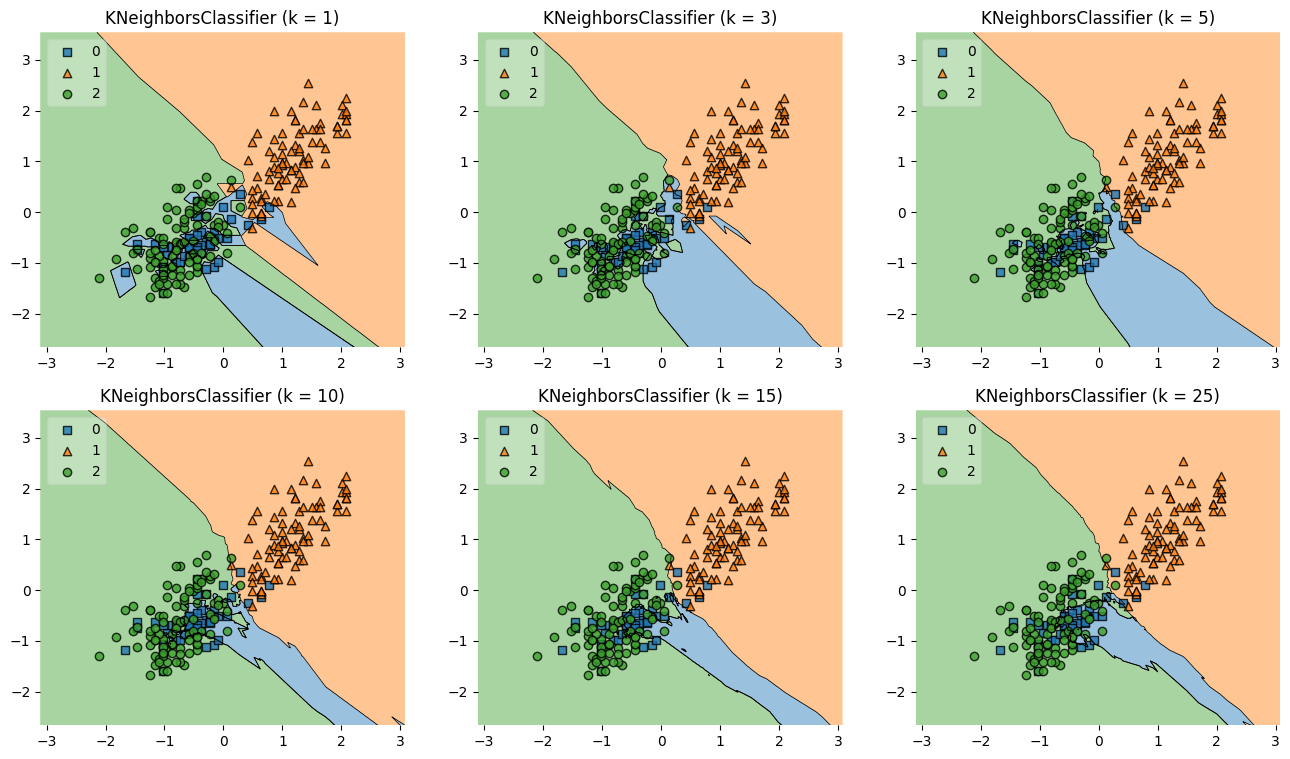

In [12]:
# В примере пингвинчики закодированы в алфавитном порядке, ваш вариант будет отличаться.

from mlxtend.plotting import plot_decision_regions

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i in range(6):
    plot_decision_regions(X_train_scaled, y_train.values, clf=knns[i], legend=2, ax=axes[i // 3, i % 3])
    axes[i // 3, i % 3].set_title(f"KNeighborsClassifier (k = {ns[i]})")

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Оптимальным является использование 5-ти ближайших соседей. Это даёт максимальную точность на тестовой и тренировочной выборке. При этом области не являются "рваными" как при меньшем значении k, и не начинает выраждаться какой-либо класс, как в случаях с бОльшим k.

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

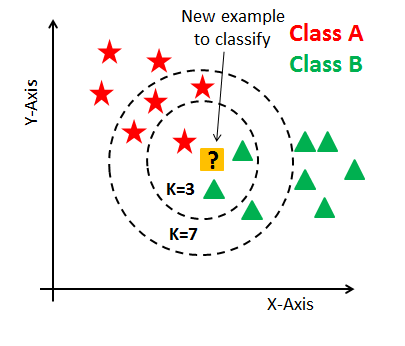

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [13]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):
        self.X = np.array(X)
        self.y = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predicts = np.zeros(X.shape[0])

        for i in range(X.shape[0]):
            distances = self.count_distance(self.X, X[i])
            k_nearest_neighbor_indices = np.argsort(distances)[0:self.k]
            k_nearest_neighbors = self.y[k_nearest_neighbor_indices]
            counter = Counter(k_nearest_neighbors)

            predicts[i] = counter.most_common(1)[0][0]
        
        return predicts

    def count_distance(self, x, y):
        return np.sqrt(np.sum((x - y) ** 2, axis=1))

In [14]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [15]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [16]:
scaler = StandardScaler()

numeric_cols = ["Date Egg", "Culmen Length (mm)", "Culmen Depth (mm)", 
                "Flipper Length (mm)", "Body Mass (g)", "Delta 15 N (o/oo)", 
                "Delta 13 C (o/oo)"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

accuracy = []

for i in ns:
    knn = KNN(i)
    knn.fit(X_train_scaled.values, y_train.values)
    prediction = knn.predict(X_test_scaled.values)
    accuracy.append((y_test.values == prediction).mean() * 100)

i = np.argmax(accuracy)

print(accuracy)
print(f"Лучшая точность {accuracy[i]} достичгается при k = {ns[i]}")

[np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0)]
Лучшая точность 100.0 достичгается при k = 1


Хорошая разделимость классов и достаточно большая выборака позволяет достигнуть около 100% точности при любом к.

### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [17]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [18]:
data.isna().mean()

Unnamed: 0    0.0
carat         0.0
cut           0.0
color         0.0
clarity       0.0
depth         0.0
table         0.0
price         0.0
x             0.0
y             0.0
z             0.0
dtype: float64

In [19]:
transformed_data = data
transformed_data.drop("Unnamed: 0", inplace=True, axis=1)


В данных не было пропусков, но был столбец с айди "Unnamed: 0", не нужный для модели.

**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

<Axes: >

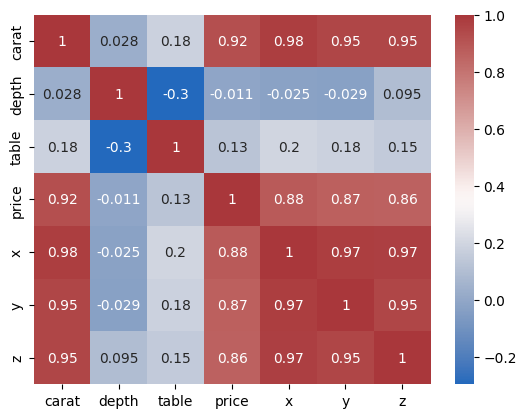

In [20]:
from seaborn import heatmap
corr_matr = transformed_data.select_dtypes(include="number").corr()
heatmap(corr_matr, annot=True, cmap="vlag")

Целевая переменная сильно коррелирована с параметрами описывающими размер и вес брильянта, при этом они сильно коррелированы и между собой. Но почти не связаны с ценой параметры "table" и "depth". 

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [21]:
transformed_data = pd.get_dummies(transformed_data, columns=["cut",	"color", "clarity"], dtype=int)
transformed_data

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,1,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,0,0,1,...,0,0,0,0,1,0,0,0,0,0
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,0,1,0,...,0,0,0,0,1,0,0,0,0,0
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,0,0,0,...,0,0,0,0,1,0,0,0,0,0
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,0,0,0,...,0,0,0,0,0,1,0,0,0,0


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [22]:
X = transformed_data.drop("price", axis=1)
y = transformed_data["price"]

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [23]:
scaler = StandardScaler()

scaled_cols = ["carat", "depth", "table", "x", "y", "z"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test_scaled[scaled_cols] = scaler.transform(X_test[scaled_cols])

Теряется связь с исходными единицами измерения, но появляется возможность сравнивать влияние разных признаков: чем больше вес по модулю - тем больше влияние параметра.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"MSE на train: {train_mse} и test: {test_mse}")

MSE на train: 1290541.9147450614 и test: 1244765.4357158681


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [25]:
standart_coef = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coef": model.coef_,
    "abs_coef": np.abs(model.coef_)}
).sort_values('abs_coef', ascending=False)

standart_coef

,feature,coef,abs_coef
0,carat,5338.615671,5338.615671
18,clarity_I1,-3889.609765,3889.609765
19,clarity_IF,1569.427535,1569.427535
17,color_J,-1546.675235,1546.675235
24,clarity_VVS1,1211.725416,1211.725416
25,clarity_VVS2,1138.685765,1138.685765
21,clarity_SI2,-1107.669217,1107.669217
3,x,-1100.418850,1100.418850
11,color_D,835.314553,835.314553
22,clarity_VS1,768.224542,768.224542


Наиболее значимые параметры: carat и clarity_I1.

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [26]:
from sklearn.linear_model import Lasso, Ridge

lasso_model = Lasso(10)
ridge_model = Ridge(10)

lasso_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)

lasso_coef = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coef": lasso_model.coef_,
    "abs_coef": np.abs(lasso_model.coef_)}
).sort_values('abs_coef', ascending=False)

ridge_coef = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coef": ridge_model.coef_,
    "abs_coef": np.abs(ridge_model.coef_)}
).sort_values('abs_coef', ascending=False)

print("Коэффициенты Lasso:")
print(lasso_coef)

Коэффициенты Lasso:
          feature         coef     abs_coef
0           carat  4853.407399  4853.407399
18     clarity_I1 -3635.745900  3635.745900
17        color_J -1649.844484  1649.844484
21    clarity_SI2 -1525.264690  1525.264690
16        color_I  -846.577963   846.577963
19     clarity_IF   725.386305   725.386305
3               x  -696.794327   696.794327
20    clarity_SI1  -617.768774   617.768774
24   clarity_VVS1   538.334305   538.334305
25   clarity_VVS2   512.220009   512.220009
6        cut_Fair  -443.367031   443.367031
15        color_H  -433.428710   433.428710
11        color_D   350.361780   350.361780
12        color_E   176.452657   176.452657
22    clarity_VS1   160.056750   160.056750
13        color_F   131.487166   131.487166
1           depth  -100.465142   100.465142
8       cut_Ideal    83.506570    83.506570
2           table   -80.372165    80.372165
5               z   -32.599937    32.599937
7        cut_Good   -32.472340    32.472340
23    clarit

In [27]:
print("Коэффициенты Ridge:")
print(ridge_coef)

Коэффициенты Ridge:
          feature         coef     abs_coef
0           carat  5298.926724  5298.926724
18     clarity_I1 -3815.493748  3815.493748
19     clarity_IF  1549.243032  1549.243032
17        color_J -1535.976045  1535.976045
24   clarity_VVS1  1199.643561  1199.643561
25   clarity_VVS2  1127.765738  1127.765738
21    clarity_SI2 -1111.447632  1111.447632
3               x -1058.745121  1058.745121
11        color_D   830.398469   830.398469
22    clarity_VS1   757.957050   757.957050
16        color_I  -637.518249   637.518249
12        color_E   614.575881   614.575881
6        cut_Fair  -594.943225   594.943225
13        color_F   558.387548   558.387548
23    clarity_VS2   438.420152   438.420152
14        color_G   333.496909   333.496909
8       cut_Ideal   254.502004   254.502004
9     cut_Premium   185.250613   185.250613
15        color_H  -163.364514   163.364514
10  cut_Very Good   152.181959   152.181959
20    clarity_SI1  -146.088154   146.088154
1           

Веса некоторых параметров значительно уменьшились.
На примере Lasso хорошо видно, что в выборке были колинеарные параметры: "y", "cut_Premium", "color_G" и "cut_Very Good".

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

d:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.548e+07, tolerance: 6.061e+07
  model = cd_fast.enet_coordinate_descent(
C:\Users\ilaes\AppData\Local\Temp\ipykernel_17908\831398163.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


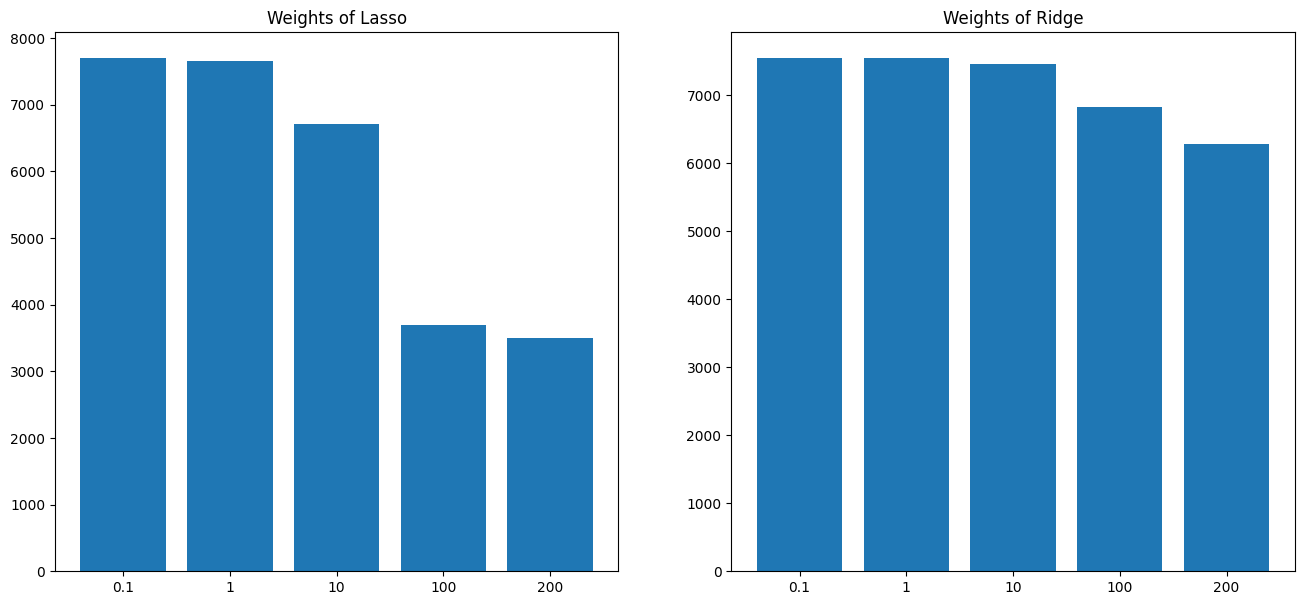

In [28]:
aes = [0.1, 1, 10, 100, 200]

w_norms_lasso = []
w_norms_ridge = []

for a in aes:
    lasso_model_a = Lasso(a)
    ridge_model_a = Ridge(a)

    lasso_model_a.fit(X_train_scaled, y_train)
    ridge_model_a.fit(X_train_scaled, y_train)

    w_norms_lasso.append(np.linalg.norm(lasso_model_a.coef_))
    w_norms_ridge.append(np.linalg.norm(ridge_model_a.coef_))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].set_title("Weights of Lasso")
axes[0].bar(list(map(str, aes)), w_norms_lasso)

axes[1].set_title("Weights of Ridge")
axes[1].bar(list(map(str, aes)), w_norms_ridge)

fig.show()


Сильнее снижает веса Lasso. Lasso-регрессию часто используют для отбора признаков потому, что она обнуляет коэффициенты незначимых признаков.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [29]:
from sklearn.linear_model import LassoCV

lcv = LassoCV(alphas=aes, cv=5)
lcv.fit(X_train_scaled, y_train)

mse_aes = np.mean(lcv.mse_path_, axis=1)
mse_aes

aes_mse = pd.DataFrame(
    {
        "alpha": lcv.alphas_,
        "mean_MSE": np.round(mse_aes)
    })

aes_mse

d:\python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.118e+08, tolerance: 4.848e+07
  model = cd_fast.enet_coordinate_descent_gram(


,alpha,mean_MSE
0,200.0,2454496.0
1,100.0,2253982.0
2,10.0,1330614.0
3,1.0,1293927.0
4,0.1,1295630.0


In [30]:
print(f"Наименьшее значение ошибки достигается при alpha = {aes_mse.loc[aes_mse["mean_MSE"].argmin()]["alpha"]}")

Наименьшее значение ошибки достигается при alpha = 1.0


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [31]:
lasso = Lasso(1)
lasso.fit(X_train_scaled, y_train)
w_lasso = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coef": lasso.coef_,
    "abs_coef": np.abs(lasso.coef_)}
).sort_values('abs_coef', ascending=False)

w_lasso

,feature,coef,abs_coef
0,carat,5290.023058,5290.023058
18,clarity_I1,-4357.890153,4357.890153
17,color_J,-1858.437047,1858.437047
21,clarity_SI2,-1643.294506,1643.294506
3,x,-1061.663033,1061.663033
19,clarity_IF,991.165423,991.165423
16,color_I,-962.758336,962.758336
6,cut_Fair,-714.616558,714.616558
20,clarity_SI1,-679.818400,679.818400
24,clarity_VVS1,650.461728,650.461728


Самые главные параметры:
- carat - т.к. цена брилианта прямо зависит от его размеров и веса.
- claity (I1, SI2, IF) - цена сильно зависит от того, на сколько чистый брилиант.
- color (J, I) - брилианты определеных цветов ценятся на рынке больше, чем другие.
- x - так же как и цена, размер сильно влияет на цену.

Неинформативные параметры:
- y и z - т.к. обычно брилиант имеет устойчивые соотношения сторон, и для описания его размера достаточно одной величины - x.
- color, cut, clarity - т.к. все эти параметры зависимы внутри своих групп
- depth - т.к. это еще одна характеристика размера зависящая от x, y, z 

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [32]:
lasso_train_mse = mean_squared_error(y_train, lasso.predict(X_train_scaled))
lasso_test_mse = mean_squared_error(y_test, lasso.predict(X_test_scaled))

cmp = pd.DataFrame({
    "linear model": np.round([train_mse, test_mse]),
    "lasso model": np.round([lasso_train_mse, lasso_test_mse])
}, index=["train", "test"])

cmp

,linear model,lasso model
train,1290542.0,1290919.0
test,1244765.0,1244173.0


У меня получилось, что MSE примерно одинаковое и для lasso и для обычной линейной модели. Но в этом случае лучше будет использовать lasso, т.к. в выборке есть коллинеарные признаки, которые можно будет выбрасить с помощью lasso.